# 05 — Epoch Folding

This notebook folds the photon arrival-time data using the detected pulsation period.

## Objectives

- use the detected pulsar period;
- convert photon arrival times into pulse phases;
- build a folded pulse profile;
- visualize the repeating structure of the signal.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "lines.linewidth": 2,
})

data_path = Path("../data/raw/vela_photons.fits")

if not data_path.exists():
    raise FileNotFoundError(
        f"Data file not found: {data_path}\n"
        "Please place vela_photons.fits into data/raw/ before running this notebook."
    )

with fits.open(data_path) as hdul:
    events = hdul[1].data

df = pd.DataFrame({
    "time": np.array(events["TIME"], dtype=np.float64),
    "energy": np.array(events["ENERGY"], dtype=np.float64),
})

df_filtered = df[df["energy"] > 100].copy()

df_filtered.head()

,time,energy
0,7.804732e+08,106.341278
1,7.805337e+08,326.514008
2,7.805415e+08,207.780685
3,7.805529e+08,229.124054
4,7.805640e+08,271.309235


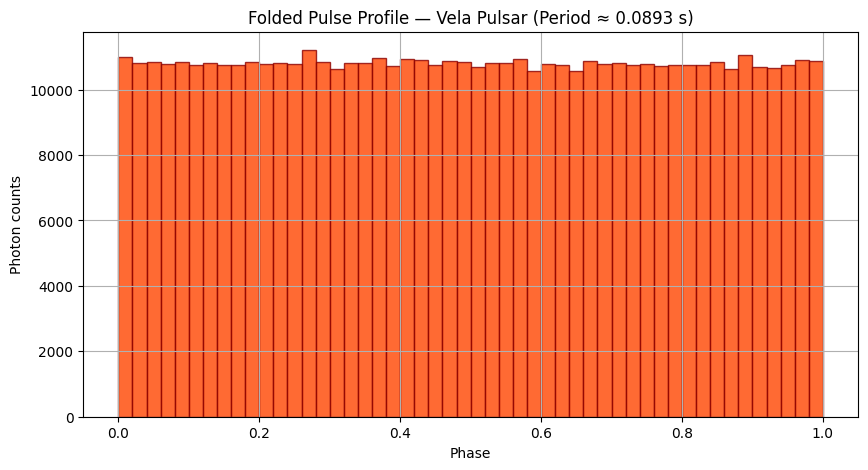

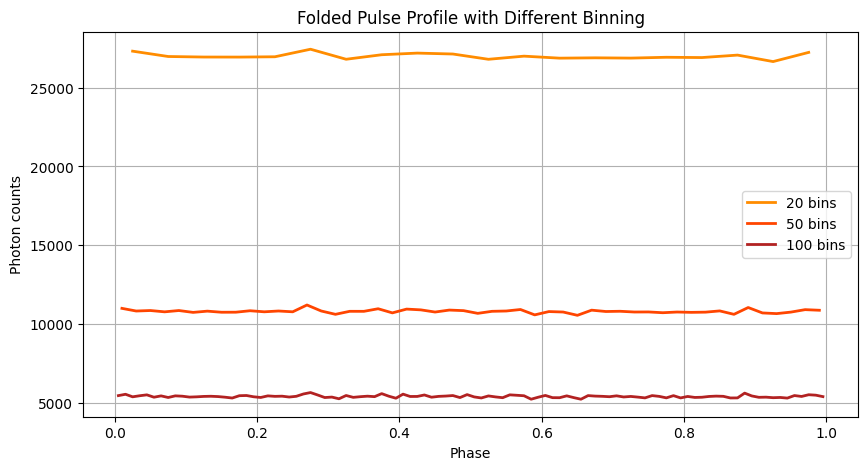

In [2]:
time = df_filtered["time"].values

dominant_period = 0.0893
dominant_freq = 1 / dominant_period

phase = (time % dominant_period) / dominant_period

n_bins = 50
counts, bin_edges = np.histogram(phase, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.bar(
    bin_centers,
    counts,
    width=1 / n_bins,
    color="orangered",
    edgecolor="darkred",
    alpha=0.8,
)
plt.xlabel("Phase")
plt.ylabel("Photon counts")
plt.title(f"Folded Pulse Profile — Vela Pulsar (Period ≈ {dominant_period:.4f} s)")
plt.show()

plt.figure()
for bins, color in zip([20, 50, 100], ["darkorange", "orangered", "firebrick"]):
    counts, bin_edges = np.histogram(phase, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.plot(bin_centers, counts, color=color, label=f"{bins} bins")

plt.xlabel("Phase")
plt.ylabel("Photon counts")
plt.title("Folded Pulse Profile with Different Binning")
plt.legend()
plt.show()


Filtered events: 540091


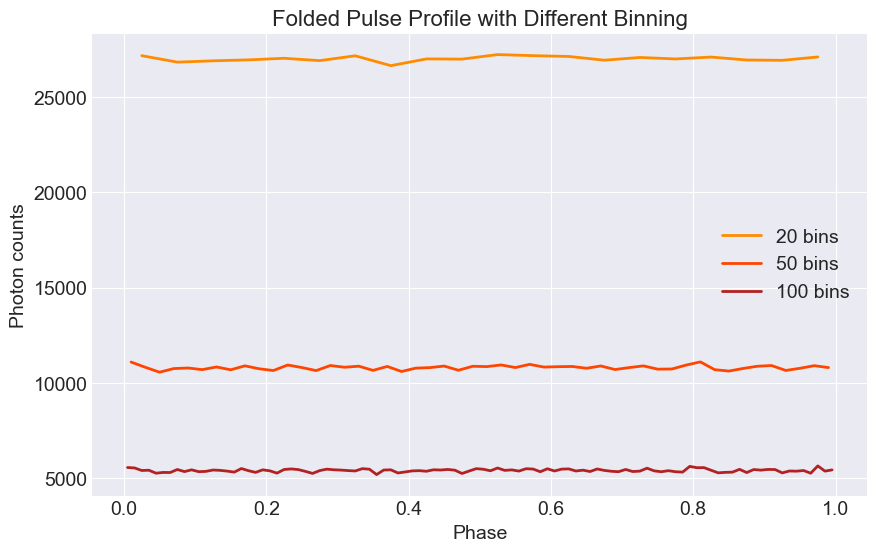

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits


plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (10,6),
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'lines.color': 'orangered',
})


hdul = fits.open('../data/raw/vela_photons.fits')
events = hdul[1].data

df = pd.DataFrame({
    "time": events["TIME"].astype('float64'),
    "energy": events["ENERGY"].astype('float64')
})


df_filtered = df[df["energy"] > 100]
print(f"Filtered events: {len(df_filtered)}")


dominant_freq = 11.2 
dominant_period = 1 / dominant_freq

time = df_filtered['time'].values
phase = (time % dominant_period) / dominant_period


n_bins = 50
counts, bin_edges = np.histogram(phase, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
for bins, color in zip([20, 50, 100], ["darkorange", "orangered", "firebrick"]):
    counts, bin_edges = np.histogram(phase, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.plot(bin_centers, counts, color=color, label=f"{bins} bins")

plt.xlabel("Phase")
plt.ylabel("Photon counts")
plt.title("Folded Pulse Profile with Different Binning")
plt.legend()
plt.show()


Filtered events: 540091


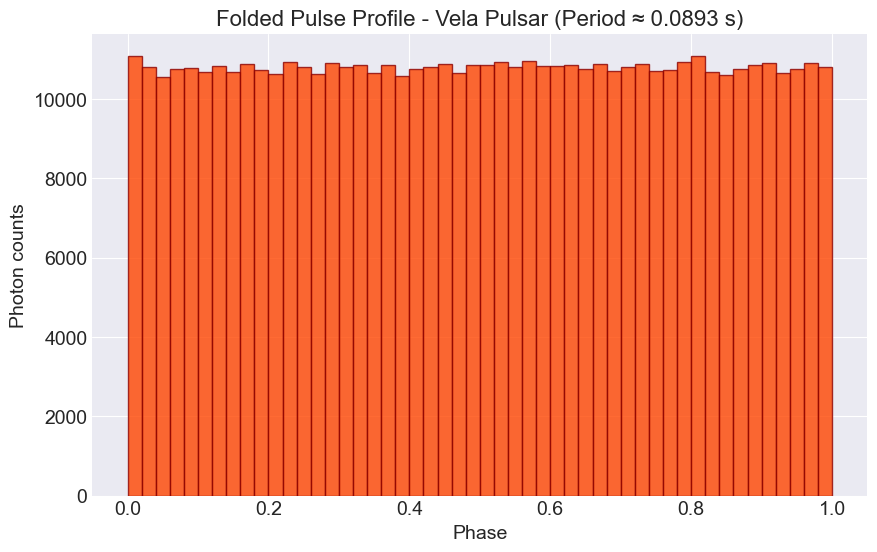

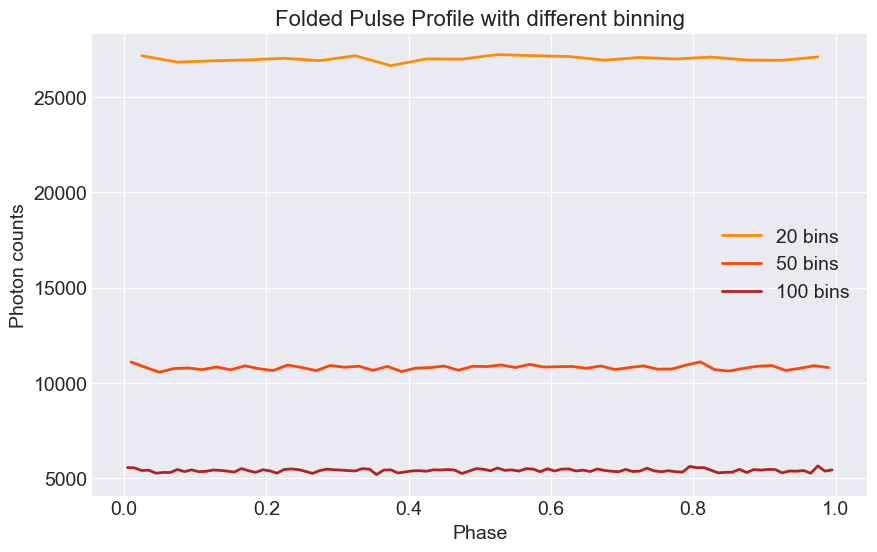

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (10,6),
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'lines.color': 'orangered',
})

hdul = fits.open('../data/raw/vela_photons.fits')
events = hdul[1].data

df = pd.DataFrame({
    "time": events["TIME"].astype('float64'),
    "energy": events["ENERGY"].astype('float64')
})

df_filtered = df[df["energy"] > 100]
print(f"Filtered events: {len(df_filtered)}")

dominant_freq = 11.2 
dominant_period = 1 / dominant_freq

time = df_filtered['time'].values
phase = (time % dominant_period) / dominant_period

n_bins = 50
counts, bin_edges = np.histogram(phase, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.bar(bin_centers, counts, width=1/n_bins, color='orangered', edgecolor='darkred', alpha=0.8)
plt.xlabel('Phase')
plt.ylabel('Photon counts')
plt.title(f'Folded Pulse Profile - Vela Pulsar (Period ≈ {dominant_period:.4f} s)')
plt.show()

plt.figure()
for bins, color in zip([20, 50, 100], ['darkorange', 'orangered', 'firebrick']):
    counts, bin_edges = np.histogram(phase, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.plot(bin_centers, counts, color=color, label=f'{bins} bins')
plt.xlabel('Phase')
plt.ylabel('Photon counts')
plt.title('Folded Pulse Profile with different binning')
plt.legend()
plt.show()


In [5]:
import os
import matplotlib.pyplot as plt

images_dir = 'images'
os.makedirs(images_dir, exist_ok=True)

figures = [plt.figure(n) for n in plt.get_fignums()]

notebook_name = '04_epoch_folding'

for i, fig in enumerate(figures, start=1):
    filename = f"{notebook_name}_fig{i}.png"
    filepath = os.path.join(images_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath}")

plt.close('all')


## Conclusion

The photon arrival-time data was folded using the detected pulsation period.  
The resulting pulse profile shows the repeating structure of the pulsar signal.